In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

sns.set_style('whitegrid')

In [2]:
# Load and Explore the Dataset
column_names = ['letter'] + [f'feature_{i}' for i in range(1, 17)]
df = pd.read_csv(
    r"d:\SPPU-CSE-SEM8-Codes\LP-V\DL\2.Letter Recognition\letter-recognition.data",
    header=None,
    names=column_names
)

print('Dataset shape:', df.shape)
display(df.head())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Dataset shape: (20000, 17)


,letter,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10



Data types:
letter        object
feature_1      int64
feature_2      int64
feature_3      int64
feature_4      int64
feature_5      int64
feature_6      int64
feature_7      int64
feature_8      int64
feature_9      int64
feature_10     int64
feature_11     int64
feature_12     int64
feature_13     int64
feature_14     int64
feature_15     int64
feature_16     int64
dtype: object

Missing values:
letter        0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
dtype: int64


In [3]:
# Preprocess the Data
X = df.drop('letter', axis=1)
y = df['letter']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print('Number of classes:', len(label_encoder.classes_))
print('Classes:', label_encoder.classes_)

# Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Number of classes: 26
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Train shape: (16000, 16) (16000, 26)
Test shape: (4000, 16) (4000, 26)


In [4]:
# Build the Deep Neural Network Model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.summary()

c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,194 (184.35 KB)

 Trainable params: 47,194 (184.35 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Train the Model
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5213 - loss: 1.6124 - val_accuracy: 0.7581 - val_loss: 0.8075
Epoch 2/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7185 - loss: 0.8890 - val_accuracy: 0.8259 - val_loss: 0.6139
Epoch 3/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7713 - loss: 0.7208 - val_accuracy: 0.8497 - val_loss: 0.5099
Epoch 4/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8020 - loss: 0.6259 - val_accuracy: 0.8741 - val_loss: 0.4258
Epoch 5/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8232 - loss: 0.5528 - val_accuracy: 0.8906 - val_loss: 0.3777
Epoch 6/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8399 - loss: 0.5043 - val_accuracy: 0.8959 - val_loss: 0.3444
Epoch 7/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.4643 - val_accuracy: 0.9100 - val_loss: 0.3113
Epoch 8/25
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8588 - loss: 0.4332 - val_accuracy: 0.

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.9575

Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.97      0.98       158
           B       0.88      0.95      0.91       153
           C       0.92      0.99      0.95       147
           D       0.95      0.96      0.96       161
           E       0.93      0.96      0.95       154
           F       0.93      0.99      0.96       155
           G       0.94      0.92      0.93       155
           H       0.99      0.86      0.92       147
           I       0.99      0.90      0.94       151
           J       0.94      0.98      0.96       149
           K       0.92      0.97      0.94       148
           L       0.98      0.96      0.97       152
           M       1.00      0.97      0.98       158
           N       0.99      0.93      0.96       157
           O       0.91      0.97      0.94       150
           P       1.00      0.93      0.96     

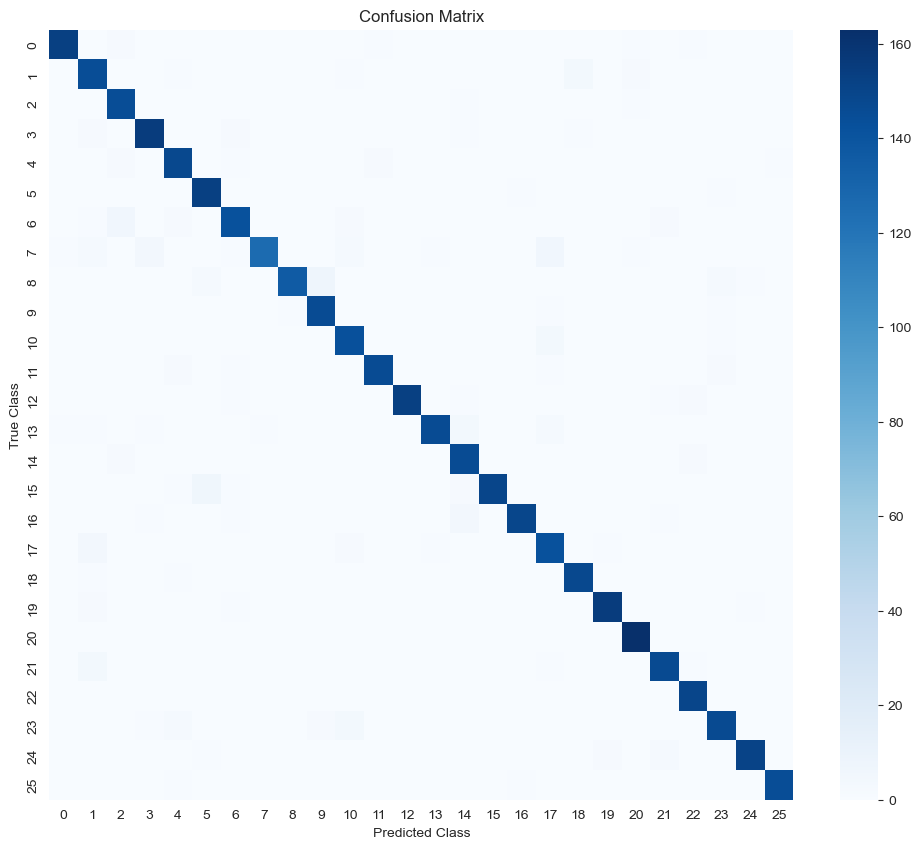

In [7]:
# Evaluate Model Performance
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('Test Accuracy:', accuracy_score(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [8]:
# Make Predictions on New Data
sample_indices = np.random.choice(len(X_test), 5, replace=False)
new_samples = X_test[sample_indices]
new_probs = model.predict(new_samples)
new_preds = np.argmax(new_probs, axis=1)
new_confidences = np.max(new_probs, axis=1)
new_actual = np.argmax(y_test[sample_indices], axis=1)

for i, idx in enumerate(sample_indices):
    print(f'Sample {i + 1}: Actual = {label_encoder.inverse_transform([new_actual[i]])[0]}, '
          f'Predicted = {label_encoder.inverse_transform([new_preds[i]])[0]}, '
          f'Confidence = {new_confidences[i]:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Sample 1: Actual = F, Predicted = F, Confidence = 0.9992
Sample 2: Actual = D, Predicted = D, Confidence = 0.8259
Sample 3: Actual = J, Predicted = J, Confidence = 1.0000
Sample 4: Actual = F, Predicted = F, Confidence = 0.9329
Sample 5: Actual = L, Predicted = L, Confidence = 1.0000


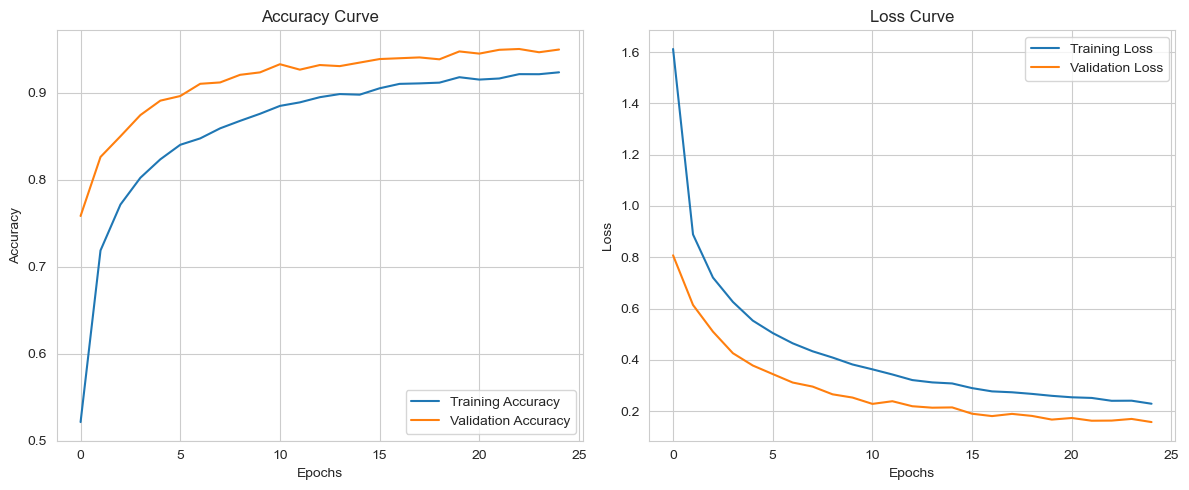

In [9]:
# Visualize Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()